# LVBench Oracle Diagnostic — Analysis & Smoke Report

**Purpose of this notebook:** a self-contained, detailed record of a new experiment (the *LVBench three-arm oracle diagnostic*) built on 2026-07-23, plus the executed smoke-test evidence that validates it. It is written so another LLM (or a human) can read top-to-bottom and produce an accurate summary.

**How to read it:** Sections 1–5 are narrative context (what/why/how). Sections 6–9 are *executed* evidence from a 4-question smoke run (accuracy, oracle mechanics, token flow, per-arm reasoning traces, montages). Section 10 is interpretation and what the next step decides.

> ⚠️ The smoke numbers use **n = 4 questions** — statistically meaningless. The smoke's job is to prove the machinery is correct and inspectable, NOT to measure accuracy. The real measurement is the paired pilot (Section 10), not yet run.

## TL;DR

- **Project north star:** treat *visual compression/perception as an action a video agent takes* — learn a policy that allocates visual bandwidth (wide+coarse vs narrow+detailed) to answer better. The open question of the current chapter: **is the missing capability a learned WHEN-to-widen/zoom/answer + WHERE-to-look policy?**
- **Why this experiment:** prior paired runs on VideoMME-long showed zero-shot tool use *churns symmetrically* (≈0 net gain); the biggest untapped lever was the **21% of questions where the agent never gathered the answer-bearing evidence**. But VideoMME-long has **no ground-truth evidence timestamps**, so you can't separate *"tools can't help"* from *"agent looked in the wrong place."*
- **The idea:** **LVBench ships a per-question `time_reference`** (a `MM:SS-MM:SS` GT evidence span). Use it as an **oracle** to script the intended coarse→fine trajectory, and measure whether *correct localization* makes the tools useful — an **upper bound** on what a perfect WHERE-policy would buy.
- **Three arms** (same model, skim, prompt, decoder; only the difference noted): **(1) Direct** (no tools), **(2) Autonomous** (crop+compress, model decides), **(3) Oracle** (harness *forces* compress→crop at the GT span, then answers).
- **The training-justifying pattern to look for:** `Direct = wrong, Autonomous = wrong, Oracle = right`. If that's common → localization is the bottleneck → SFT/RL on WHEN/WHERE is justified. If the Oracle *also* fails → the evidence itself is insufficient and the chapter must rethink.
- **Status:** harness built + **smoke-verified end-to-end** (this notebook). Paired pilot pending.

## 1. Research context & motivation

The agent under study is **zero-shot Qwen3-VL-8B-Instruct** driving a small tool loop over long videos:
- **initial view:** 64 frames uniformly sampled across the whole video (a sparse "skim").
- **`crop_video(start,end)`** — zoom a tight span to *full detail* (≤128 frames @1fps).
- **`compress_video(start,end)`** — a *compressed overview* of a long span (real in-model FlashVID: many frames at the same token cost as a crop, trading per-frame detail for temporal coverage).
- **`answer`** — emit `<answer>X</answer>` (A–D).

On **VideoMME-long** (paired 882-question runs), giving the model these tools produced **~0 net accuracy change but ~15% of answers flipped** — symmetric churn, not signal. A blind evidence-chain audit found the dominant *headroom* bucket (of the questions both arms got wrong) was **21% "never gathered"**: nothing the agent looked at ever covered the evidence. That points at a **localization / WHEN-to-look policy**, not a perception or compression-mechanics problem.

**The blocker for proving it:** VideoMME-long has no per-question evidence timestamps. You cannot tell, on a wrong answer, whether the tools *couldn't* help or whether the agent simply *never looked in the right place*.

**LVBench resolves this.** Each question carries `time_reference` — a `MM:SS-MM:SS` GT evidence span. That lets us *force* the agent to look in exactly the right place (oracle) and ask: **given correct localization, do the tools + the model's reasoning actually produce the right answer?**

## 2. The three arms

All three arms are **identical** except where noted: same weights (Qwen3-VL-8B), same 64-frame initial skim, same question text, same greedy decoding, same `<answer>` parser, same bounded finalizer, and the **same question set** (paired). The *only* differences:

| # | Arm | `run_eval --arm` | Tools visible | Who chooses the spans | Measures |
|---|-----|------------------|---------------|------------------------|----------|
| 1 | **Direct** | `baseline` | none | — (one generation, no tools) | the base model's raw video-QA ability |
| 2 | **Autonomous** | `compress` | crop + compress | **the model** (agent loop) | the model's *native* zero-shot tool-use / evidence-allocation policy |
| 3 | **Oracle** | `oracle` | crop + compress | **the harness**, from `time_reference` | whether tools+reasoning work *when localization is correct* (a diagnostic upper bound, not a deployable policy) |

Because arms 2 and 3 differ **only in who picks the spans**, a paired comparison isolates the value of correct localization.

## 3. The oracle mechanism (arm 3)

The harness scripts the intended **coarse → fine** trajectory the autonomous agent fails to reliably discover:

```
initial 64-frame skim
   → compress_video( evidence-widened window )      # broad context
   → crop_video( GT evidence span )                  # precise detail
   → <answer>                                         # one final reasoned generation
```

**Span derivation** from the GT evidence span `[es, ee]` (seconds), video duration `D`:
- **compress** `= clamp( es − 300 , ee + 300 )` to `[0, D]` — an *evidence-widened* window (per design decision: broad context, but NOT the whole video).
- **crop** `= [es, ee]`, widened symmetrically to a **≥16 s floor** if the reference is tighter (so a 3-second reference still yields ~16 full-detail frames), clamped to `[0, D]`. If the span exceeds the crop budget (128 frames @1fps ≈ 128 s) it is uniformly sub-sampled to 128 *full-resolution* frames — still the right region, just coarser in time.

**Faithfulness controls:** the forced tool calls are synthesized by the harness (no model decision) but the **model-facing text is identical** to a real agent run — a normal `<tool_call>` + `<tool_response>` carrying the compressed/cropped frames. The `oracle_forced=True` marks live **only in the logged trajectory**, so the model never knows the spans were supplied. A **single final generation** reasons over skim+compress+crop and answers (no reasoning between the forced steps — that mode was previously found to be repetition-prone under greedy decoding).

## 4. What was built (files, branch, environment)

**Git:** branch `lvbench-pivot` in the `longvt_compression` repo (2 commits). VideoMME path untouched; existing runs preserved.

| File | Change |
|------|--------|
| `fast_agent/data.py` | `load_lvbench()` (reads the zai-org `video_info.meta.jsonl`, **not** the flattened `LVBench.tsv` which drops `time_reference`), `parse_time_reference()`, `load_dataset()` dispatcher. Emits the VideoMME row schema **+ `evidence`**. |
| `fast_agent/config.py` | LVBench paths; oracle knobs `ORACLE_COMPRESS_MARGIN=300`, `ORACLE_CROP_MIN_WIDTH=16`. |
| `fast_agent/oracle.py` (new) | `run_oracle_sample()` + `oracle_spans()` — the forced trajectory, reusing the existing encode/inject/trajectory machinery; emits the same result + trajectory schema as the autonomous loop. |
| `fast_agent/run_eval.py` | `--dataset {videomme,lvbench}` flag (default videomme → non-breaking); `oracle` arm dispatch (guarded to lvbench + rows with evidence). |

**Dataset facts (verified on all 1,549 QAs):** 103 videos; every QA is 4-option (A–D) with a `time_reference`; **2** malformed refs flagged (excluded from the oracle arm only); **263** zero-width refs (handled by the crop min-width floor); refs up to 140 min; some LVBench videos are **AV1** (handled by the harness's existing h264-proxy path).

**Environment note:** the `vllm` conda env had lost `flash_attn` in a torch→2.10.0+cu129 upgrade, which blocks *every* arm (FlashVID's patched vision attention hard-requires `flash_attention_2`; `sdpa` is a proven dead end). Fixed by **source-building flash-attn 2.8.3.post1 against torch 2.10** (nvcc 12.4, `MAX_JOBS=16`); import + kernel verified.

## 5. The smoke test

4 fixed LVBench questions spanning tight→wide evidence and different task types, run through all three arms with a single model load, plus a 2-question VideoMME regression to prove non-breaking. **The numbers are a machinery check, not a measurement.** The cells below load the saved runs and lay out the evidence.

In [1]:
import sys, json, os
sys.path.insert(0, "/home/cfyang/hanklin/longvt_compression")
from fast_agent import viz, data, config

RUNROOT = "/local1/cfyang/hanklin/outputs/fast_agent/runs"
ARMS = ["baseline", "compress", "oracle"]           # Direct / Autonomous / Oracle
ARM_LABEL = {"baseline":"1. Direct", "compress":"2. Autonomous", "oracle":"3. Oracle"}
runs = {a: viz.load_run(f"{RUNROOT}/lvbench_{a}_smoke") for a in ARMS}
by_arm_qid = {a: {t["question_id"]: t for t in runs[a]} for a in ARMS}
QIDS = [t["question_id"] for t in runs["oracle"]]     # 4 smoke qids

# LVBench metadata (evidence spans / time_reference) for these qids
lv = {r["question_id"]: r for r in data.load_lvbench()}
print("Smoke question set:")
for q in QIDS:
    r = lv[q]; es,ee = r["evidence"]
    print(f"  qid {q:5s} | {r['task_type']:20s} | ref {r['time_reference']:13s} "
          f"(width {ee-es:.0f}s) | gold {r['answer']} | video {r['videoID']} ({data.video_duration(r['video_path'])/60:.0f} min)")


Smoke question set:
  qid 1246  | event understanding  | ref 43:38-43:41   (width 3s) | gold D | video aJI8XTa_DII (53 min)
  qid 1898  | entity recognition   | ref 01:24-01:40   (width 16s) | gold D | video YlQugR7KSKg (67 min)
  qid 2367  | temporal grounding   | ref 17:16-17:40   (width 24s) | gold A | video xECIRjlxM3U (126 min)
  qid 903   | reasoning            | ref 37:00-42:00   (width 300s) | gold C | video 5dZ_lvDgevk (114 min)


In [2]:
# Section 6 — per-arm accuracy summary (n=4, machinery check only)
from fast_agent.run_eval import write_summary
print(f"{'arm':16s} {'acc':>6s} {'n':>3s} {'finalizer%':>11s}   tool-call histogram")
for a in ARMS:
    s = write_summary(f"{RUNROOT}/lvbench_{a}_smoke", a)
    print(f"{ARM_LABEL[a]:16s} {s['accuracy']:>5.0f}% {s['n']:>3d} {s['finalizer_rate']:>10.0f}%   {s['tool_calls']}")
print("\n(Direct=no tools; Autonomous=model-chosen; Oracle=forced compress+crop on every question.)")


/local1/cfyang/miniconda3/envs/vllm/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Please install pyav to use video processing functions.
OpenCLIP not installed
arm                 acc   n  finalizer%   tool-call histogram
1. Direct           25%   4         50%   {}
2. Autonomous       25%   4         75%   {'compress_video': 8, 'crop_video': 2}
3. Oracle           50%   4          0%   {'compress_video': 4, 'crop_video': 4}

(Direct=no tools; Autonomous=model-chosen; Oracle=forced compress+crop on every question.)


In [3]:
# Section 6b — per-question outcome across the three arms (the paired view)
def preds(q):
    row=[]
    for a in ARMS:
        t=by_arm_qid[a].get(q,{})
        tools="+".join((c.get("action") or {}).get("name","").replace("_video","") for c in t.get("rounds",[]) if (c.get("action") or {}).get("kind")=="tool_call") or "-"
        row.append((t.get("pred"), t.get("correct"), tools))
    return row
hdr = f"{'qid':6s} {'gold':4s} | " + " | ".join(f"{ARM_LABEL[a]:>26s}" for a in ARMS)
print(hdr); print("-"*len(hdr))
for q in QIDS:
    gold = lv[q]["answer"]; cells=[]
    for (p,ok,tools) in preds(q):
        mark = "OK " if ok else "   "
        cells.append(f"{mark}pred={p} [{tools}]".ljust(26))
    print(f"{q:6s} {gold:4s} | " + " | ".join(cells))
print("\nRead: does Oracle get questions right that Direct AND Autonomous get wrong? "
      "(That is the training-justifying pattern — but n=4 here, so this is illustrative only.)")


qid    gold |                  1. Direct |              2. Autonomous |                  3. Oracle
--------------------------------------------------------------------------------------------------
1246   D    |    pred=None [-]           |    pred=C [compress+crop]  |    pred=C [compress+crop] 
1898   D    |    pred=B [-]              | OK pred=D [compress]       | OK pred=D [compress+crop] 
2367   A    |    pred=C [-]              |    pred=C [compress+crop]  |    pred=C [compress+crop] 
903    C    | OK pred=C [-]              |    pred=None [compress+compress+compress+compress+compress] | OK pred=C [compress+crop] 

Read: does Oracle get questions right that Direct AND Autonomous get wrong? (That is the training-justifying pattern — but n=4 here, so this is illustrative only.)


In [4]:
# Section 7 — ORACLE MECHANICS: span derivation + token flow (proves the forced trajectory)
print("For each oracle question: how the GT evidence span becomes the forced compress+crop, and the token budget.\n")
for q in QIDS:
    t = by_arm_qid["oracle"][q]; o = t["oracle"]
    print(f"=== qid {q}  (evidence {o['time_reference']} = {o['evidence']}s, dur {t['duration']:.0f}s) ===")
    print(f"    compress window = {[round(x) for x in o['compress_span']]}  (evidence +/-300s, clamped)")
    print(f"    crop window     = {[round(x) for x in o['crop_span']]}  (GT span, >=16s floor)")
    for r in t["rounds"]:
        a=r.get("action") or {}; tr=r.get("tool_result")
        if a.get("kind")=="tool_call" and tr:
            if tr["tool"]=="compress_video":
                print(f"    → compress: {tr['n_frames']} frames sampled → {tr['base_tokens']} base tokens "
                      f"→ FlashVID keeps {tr['kept_tokens']} (retention {tr['retention']}) | oracle_forced={a.get('oracle_forced')}")
            else:
                print(f"    → crop:     {tr['n_frames']} full-detail frames | oracle_forced={a.get('oracle_forced')}")
        elif a.get("kind")=="answer":
            print(f"    → final answer generation over ctx {r.get('context_tokens')} tokens: {(r.get('thinking') or '').strip()[:120]}")
    print()
print("Note: kept_tokens (~6.1k) is matched to the crop budget (128 frames), so compression buys temporal coverage at equal token cost.")


For each oracle question: how the GT evidence span becomes the forced compress+crop, and the token budget.

=== qid 1246  (evidence 43:38-43:41 = [2618.0, 2621.0]s, dur 3167s) ===
    compress window = [2318, 2921]  (evidence +/-300s, clamped)
    crop window     = [2612, 2628]  (GT span, >=16s floor)
    → compress: 602 frames sampled → 13545 base tokens → FlashVID keeps 6130 (retention 0.425) | oracle_forced=True
    → crop:     16 full-detail frames | oracle_forced=True
    → final answer generation over ctx 13959 tokens: <answer>C</answer>

=== qid 1898  (evidence 01:24-01:40 = [84.0, 100.0]s, dur 3997s) ===
    compress window = [0, 400]  (evidence +/-300s, clamped)
    crop window     = [84, 100]  (GT span, >=16s floor)
    → compress: 400 frames sampled → 9000 base tokens → FlashVID keeps 5891 (retention 0.64) | oracle_forced=True
    → crop:     16 full-detail frames | oracle_forced=True
    → final answer generation over ctx 12318 tokens: <answer>D</answer>

=== qid 2367  (evi

In [5]:
# Section 8 — FULL per-question, per-arm reasoning traces (the richest evidence for a summary)
def show_trace(t, arm):
    print(f"  --- {ARM_LABEL[arm]} ---  pred={t.get('pred')} correct={t.get('correct')} finalizer_used={t.get('finalizer_used')}")
    for r in t.get("rounds", []):
        a=r.get("action") or {}; kind=a.get("kind"); think=(r.get('thinking') or '').strip().replace("\n"," ")
        if kind=="tool_call":
            of = " [ORACLE-FORCED]" if a.get("oracle_forced") else ""
            print(f"      round {r['round']}: CALL {a['name']}({a['start']:.0f},{a['end']:.0f}){of}")
        elif kind in ("answer","stop","finalizer"):
            print(f"      round {r['round']} [{kind}]: {think[:400]}")
        else:
            print(f"      round {r['round']}: {think[:200]}")

for q in QIDS:
    r = lv[q]
    print("="*100)
    print(f"QUESTION {q} | {r['task_type']} | evidence {r['time_reference']}")
    print(f"  {data.format_question(r)}")
    print(f"  GOLD = {r['answer']}")
    for a in ARMS:
        show_trace(by_arm_qid[a][q], a)
    print()


QUESTION 1246 | event understanding | evidence 43:38-43:41
  How many trucks are there in the garage with soldiers in white direct the way in the next scene after the Russian plane takes off?
A. 12
B. 9
C. 8
D. 10
  GOLD = D
  --- 1. Direct ---  pred=None correct=False finalizer_used=True
      round 0 [answer]: The provided images are still frames from a video documentary, likely "Frontline" by PBS, which focuses on U.S.-Russia relations and the Ukraine conflict. The video contains interviews, historical footage, and news clips.  The question asks about a specific scene: "the next scene after the Russian plane takes off" featuring "soldiers in white direct the way in the garage with trucks". However, non
      round finalizer [finalizer]: <answer>Unknown</answer>
  --- 2. Autonomous ---  pred=C correct=False finalizer_used=True
      round 0: CALL compress_video(0,3167)
      round 1: CALL crop_video(1736,1740)
      round 2 [stop]: The scene depicts a group of soldiers in green milit

**qid 1898** — *entity recognition* — What color is the wall light around the stage?  
evidence `01:24-01:40`, gold **D**, oracle pred **D**

*64-frame whole-video skim (initial view, all arms)*

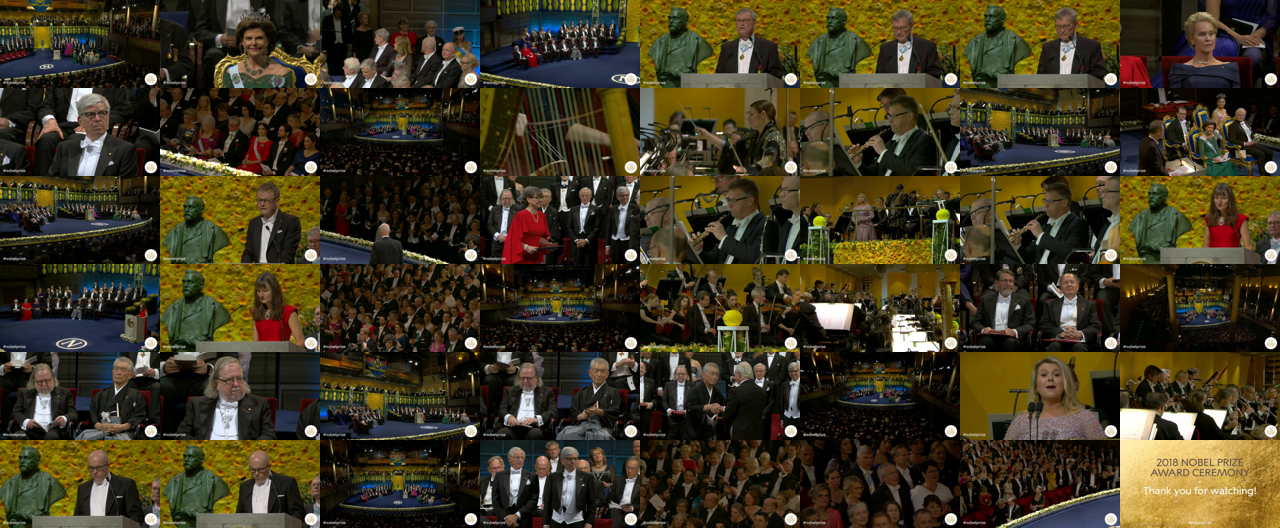

*compress_video over evidence+/-300s (broad context; frames the model actually saw, pre-compression)*

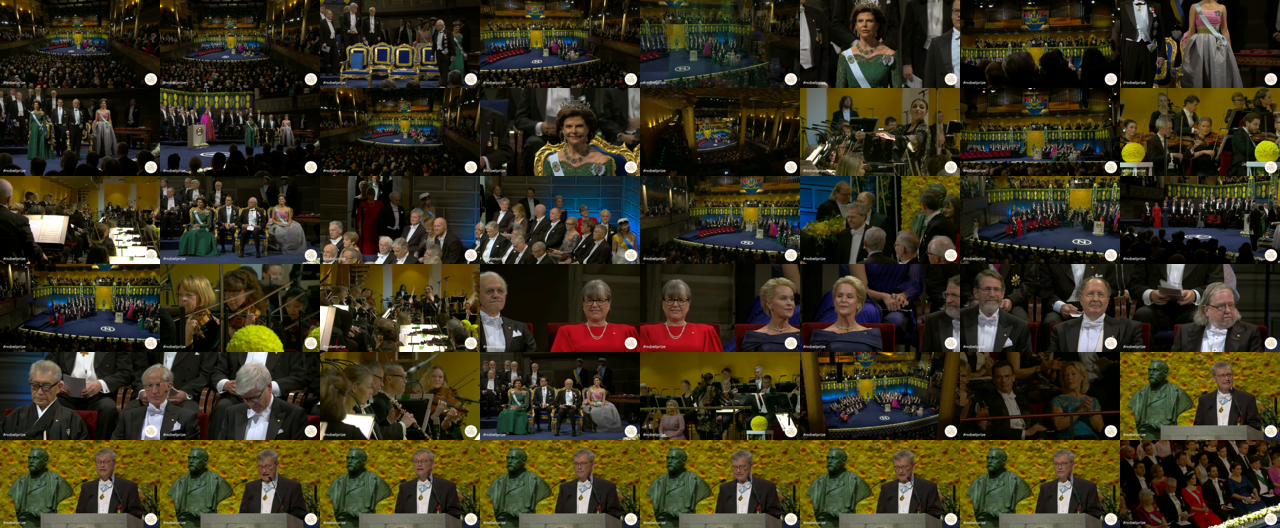

*crop_video at the GT evidence span (full detail — should show the answer)*

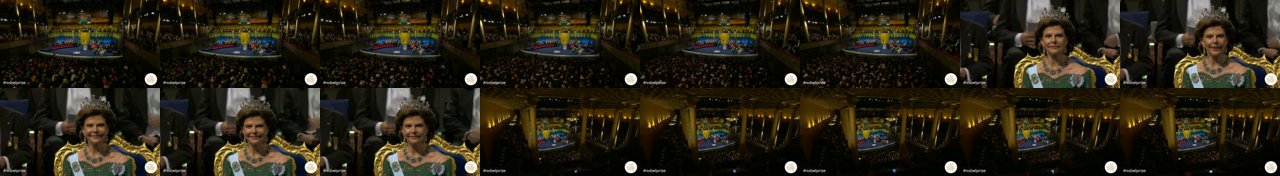

In [6]:
# Section 9 — montages for ONE oracle trajectory: skim → compressed overview → GT crop
# (visual proof the forced evidence is the right region; base64-embedded so the notebook is self-contained)
from IPython.display import Image, display, Markdown
Q = "1898"  # entity recognition, ref 01:24-01:40, gold D (wall-light color) — oracle got it right
mdir = f"{RUNROOT}/lvbench_oracle_smoke/media/{Q}"
r = lv[Q]
display(Markdown(f"**qid {Q}** — *{r['task_type']}* — {data.format_question(r).splitlines()[0]}  \n"
                 f"evidence `{r['time_reference']}`, gold **{r['answer']}**, oracle pred **{by_arm_qid['oracle'][Q]['pred']}**"))
for name, cap in [("initial.png","64-frame whole-video skim (initial view, all arms)"),
                  ("r0_compress.png","compress_video over evidence+/-300s (broad context; frames the model actually saw, pre-compression)"),
                  ("r1_crop.png","crop_video at the GT evidence span (full detail — should show the answer)")]:
    p=f"{mdir}/{name}"
    if os.path.exists(p):
        display(Markdown(f"*{cap}*")); display(Image(filename=p, width=1100))
    else:
        display(Markdown(f"*(missing {name})*"))


In [7]:
# Section 9b — contrast: the AUTONOMOUS arm's self-chosen tool calls on the same question
Q = "1898"
t = by_arm_qid["compress"][Q]
print(f"Autonomous arm on qid {Q}: pred={t['pred']} correct={t['correct']}")
print("Self-chosen tool calls:", [(c['action']['name'], round(c['action']['start']), round(c['action']['end'])) for c in t.get('rounds',[]) if (c.get('action') or {}).get('kind')=='tool_call'])
print("\n(Compare the spans the model CHOSE here vs. the GT-derived spans the oracle FORCED above.)")


Autonomous arm on qid 1898: pred=D correct=True
Self-chosen tool calls: [('compress_video', 0, 3997)]

(Compare the spans the model CHOSE here vs. the GT-derived spans the oracle FORCED above.)


## 10. Interpretation & the decision the pilot will make

**What the smoke establishes (machinery, n=4):**
- The oracle arm reliably executes the forced **compress(evidence±300s) → crop(GT span) → answer** trajectory; spans are derived correctly from `time_reference` (including the 16-second floor for tight refs and 128-frame sub-sampling for wide ones); the compressed + cropped tokens actually reach the model (context 12k–20k tokens); answers are clean.
- Direct uses no tools; Autonomous chooses its own spans (and reproduces the known over-exploration — e.g. repeatedly compressing a whole 114-minute video).
- VideoMME still runs unchanged (non-breaking).
- A concrete *evidence-present-but-wrong* case already appeared (a question whose GT crop clearly shows the annotated scene, yet the model still answered incorrectly) — exactly the failure mode the pilot must quantify.

**What the paired pilot (≈60 questions, all three arms) will measure — the actual science:**
1. **Does tool availability beat Direct?** (Autonomous vs Direct.)
2. **Does the autonomous agent locate & use evidence effectively?** (its accuracy + whether its self-chosen spans overlap the GT.)
3. **Does oracle-guided compress→crop beat both?** (Oracle vs Direct and vs Autonomous.)
4. **How big is the Autonomous→Oracle gap?** — the headroom a perfect WHERE-policy would unlock.

**The key pattern that would justify SFT/RL:**

```
Direct: wrong    Autonomous: wrong    Oracle: right      →  localization is the bottleneck; train WHEN/WHERE.
```

**The disconfirming outcomes (equally important):** if the **Oracle also fails** on the both-wrong questions, then compression+crop evidence is *insufficient* (perception/reasoning ceiling), and fixed localization is not the missing piece — the chapter would need to rethink rather than invest in training.

**Caveats to carry into any reading:**
- The custom decoder in this harness scores ~16.6pp below stock `model.generate`; **all three arms share it**, so paired *deltas* are valid, but the absolute *Direct* number is a lower bound, not the model's true ceiling.
- The autonomous compress arm is **slow** on long LVBench videos (minutes/sample) — the pilot is sized around it.
- n=4 here proves nothing about accuracy; only the pilot does.